In [1]:
import os
import yaml

import numpy as np
import pandas as pd

from natsort import natsort_keygen

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import zarr
import dask.array as da
from tifffile import imread

from PIL import Image
from numpy import asarray

from skimage.color import gray2rgb
from skimage.util.dtype import img_as_float

from utils.utility_functions import transposeZarr

plt.rcParams['font.family'] = 'Arial'

In [2]:
# data selection (uncomment one and run notebook)

# segmentation
# clustering, latent_dim = ('Seg', None)

# 9um model
clustering, latent_dim = ('VAE9_VIG7', 412)

In [3]:
# read image patch dataframe
main = pd.read_csv(os.path.join(os.getcwd(), 'input/main.csv'))

# import markers.csv
markers = pd.read_csv(os.path.join(os.getcwd(), 'input/CyCIF-1A_mcmicro_markers.csv'))

# read SARDANA-097 image contrast settings (defined in CyLinter)
contrast_dir = os.path.join(os.getcwd(), 'input/CyCIF-1A_cylinter_contrast_limits.yml')
contrast_limits = yaml.safe_load(open(contrast_dir))

if latent_dim is not None:
    # read combined training, validation, and test thumbnails
    root = os.path.join(os.getcwd(), f'input/{clustering}')
    combo_dir = os.path.join(root, f'6_latent_space_LD{latent_dim}/combined_zarr')
    X_combo = zarr.open(combo_dir)
    
    # rearrange Zarr dimensions to conform to expected VAE input
    # (i.e. cells, x, y, channels)
    X_combo = transposeZarr(z=X_combo)

# out dir
out = os.path.join(os.getcwd(), f'output/tumor_morphology')
if not os.path.exists(out):
    os.makedirs(out)

In [4]:
# compute and plot channel z-scores
channels = {
    'anti_CD3': 0, 'anti_CD45RO': 1, 'Keratin_570': 2, 'aSMA_660': 3, 'CD4_488': 4, 'CD45_PE': 5,
    'PD1_647': 6, 'CD20_488': 7, 'CD68_555': 8, 'CD8a_660': 9, 'CD163_488': 10, 'FOXP3_570': 11,
    'PDL1_647': 12, 'Ecad_488': 13, 'Vimentin_555': 14, 'CDX2_647': 15, 'LaminABC_488': 16,
    'Desmin_555': 17, 'CD31_647': 18, 'PCNA_488': 19, 'CollagenIV_647': 20
}

antibody_abbrs = {
    'Hoechst0': 'DNA', 'anti_CD3': 'CD3', 'anti_CD45RO': 'CD45RO', 'Keratin_570': 'Keratin', 'aSMA_660': 'aSMA',
    'CD4_488': 'CD4', 'CD45_PE': 'CD45', 'PD1_647': 'PD1', 'CD20_488': 'CD20', 'CD68_555': 'CD68',
    'CD8a_660': 'CD8a', 'CD163_488': 'CD163', 'FOXP3_570': 'FOXP3', 'PDL1_647': 'PDL1',
    'Ecad_488': 'ECAD', 'Vimentin_555': 'Vimentin', 'CDX2_647': 'CDX2', 'LaminABC_488': 'LaminABC',
    'Desmin_555': 'Desmin', 'CD31_647': 'CD31', 'PCNA_488': 'PCNA', 'CollagenIV_647': 'CollagenIV'
}

Seg clustering


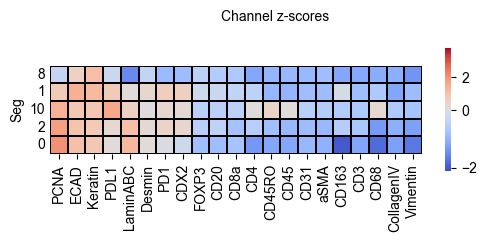

In [5]:
print ('Seg clustering')

# compute mean intensity of cells per cluster
clustermap_seg = main[list(channels.keys()) + ['Seg']].groupby('Seg').mean()

# compute per channel z-scores across clusters
clustermap_seg = (clustermap_seg-clustermap_seg.mean())/clustermap_seg.std()

# zero-center colorbar
norm_seg = TwoSlopeNorm(vcenter=0, vmin=clustermap_seg.min().min(), vmax=clustermap_seg.max().max())

fig, ax = plt.subplots(figsize=(6, 2))
clustermap_seg = clustermap_seg[clustermap_seg.index.isin([0, 1, 2, 8, 10])]
clustermap_seg = clustermap_seg.loc[:, clustermap_seg.mean(axis=0).sort_values(ascending=False).index]
clustermap_seg = clustermap_seg.sort_values(by='PCNA_488', ascending=True)

clustermap_object = sns.heatmap(
        clustermap_seg, cmap='coolwarm', square=True, yticklabels=1, xticklabels=1,
        linewidths=0.1, linecolor='k', cbar=True, norm=norm_seg, cbar_kws={'shrink': 0.8} 
    )
clustermap_object.set_xticklabels(
    [antibody_abbrs[i.get_text()] for i in clustermap_object.get_xticklabels()], rotation=90
)
clustermap_object.set_yticklabels(
    [i.get_text() for i in clustermap_object.get_yticklabels()], rotation=0
)

clustermap_object.get_figure().suptitle('Channel z-scores', y=0.995, fontsize=10)
clustermap_object.yaxis.set_tick_params(length=0.05, width=0.01)

plt.savefig(os.path.join(out, 'seg_channel_z-scores.pdf'), bbox_inches='tight')
plt.show()

Pixel clustering


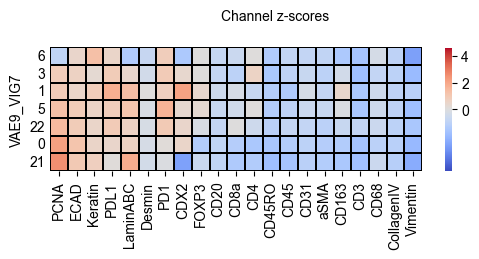

In [6]:
print ('Pixel clustering')

# compute median values of per patch, per channel pixel intensity medians
medians = da.median(X_combo, axis=(1, 2)).compute()
clustermap_input = pd.DataFrame(columns=[i for i in channels.keys()], data=medians)
clustermap_input[clustering] = main[clustering]
clustermap_pixel = clustermap_input.groupby(clustering).median()

# compute per channel z-scores across clusters
clustermap_pixel = (clustermap_pixel-clustermap_pixel.mean())/clustermap_pixel.std()

# zero-center colorbar
norm_pixel = TwoSlopeNorm(vcenter=0, vmin=clustermap_pixel.min().min(), vmax=clustermap_pixel.max().max())

fig, ax = plt.subplots(figsize=(6, 2))
clustermap_pixel = clustermap_pixel[clustermap_pixel.index.isin([0, 1, 3, 5, 6, 21, 22])]
clustermap_pixel = clustermap_pixel[clustermap_seg.columns]
clustermap_pixel = clustermap_pixel.sort_values(by='PCNA_488', ascending=True)

clustermap_object = sns.heatmap(
        clustermap_pixel, cmap='coolwarm', square=True, yticklabels=1, xticklabels=1,
        linewidths=0.1, linecolor='k', cbar=True, norm=norm_pixel, cbar_kws={'shrink': 0.8}
    )
clustermap_object.set_xticklabels(
    [antibody_abbrs[i.get_text()] for i in clustermap_object.get_xticklabels()], rotation=90
)
clustermap_object.set_yticklabels(
    [i.get_text() for i in clustermap_object.get_yticklabels()], rotation=0
)
clustermap_object.get_figure().suptitle('Channel z-scores', y=0.995, fontsize=10)
clustermap_object.yaxis.set_tick_params(length=0.05, width=0.01)

plt.savefig(os.path.join(out, 'pixel_channel_z-scores.pdf'), bbox_inches='tight')
plt.show()